In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
train_df = pd.read_csv('data/잔액정보_with_segment.csv')
train_df

,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,...,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M,Segment
0,201807,TRAIN_000000,998,962,22971,0,0,0,1084,547,...,2440,0,0,0,572,0,17008,0,0,D
1,201807,TRAIN_000001,2565,2390,0,0,0,0,4090,2553,...,2677,0,2830,0,2736,0,0,0,0,E
2,201807,TRAIN_000002,5312,5113,21531,6795,0,0,5006,8778,...,9118,0,8870,0,4429,0,43351,0,0,C
3,201807,TRAIN_000003,730,5025,26284,0,0,0,487,5607,...,884,0,0,0,5097,0,30697,0,0,D
4,201807,TRAIN_000004,0,0,0,0,0,0,0,0,...,21,0,0,0,0,0,0,0,0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
2399996,201812,TRAIN_399996,3351,0,0,0,0,27337,4412,0,...,12524,0,0,0,0,0,0,0,23031,D
2399997,201812,TRAIN_399997,2524,2960,0,0,0,0,2694,3374,...,3241,0,0,0,3995,0,0,0,0,C
2399998,201812,TRAIN_399998,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E


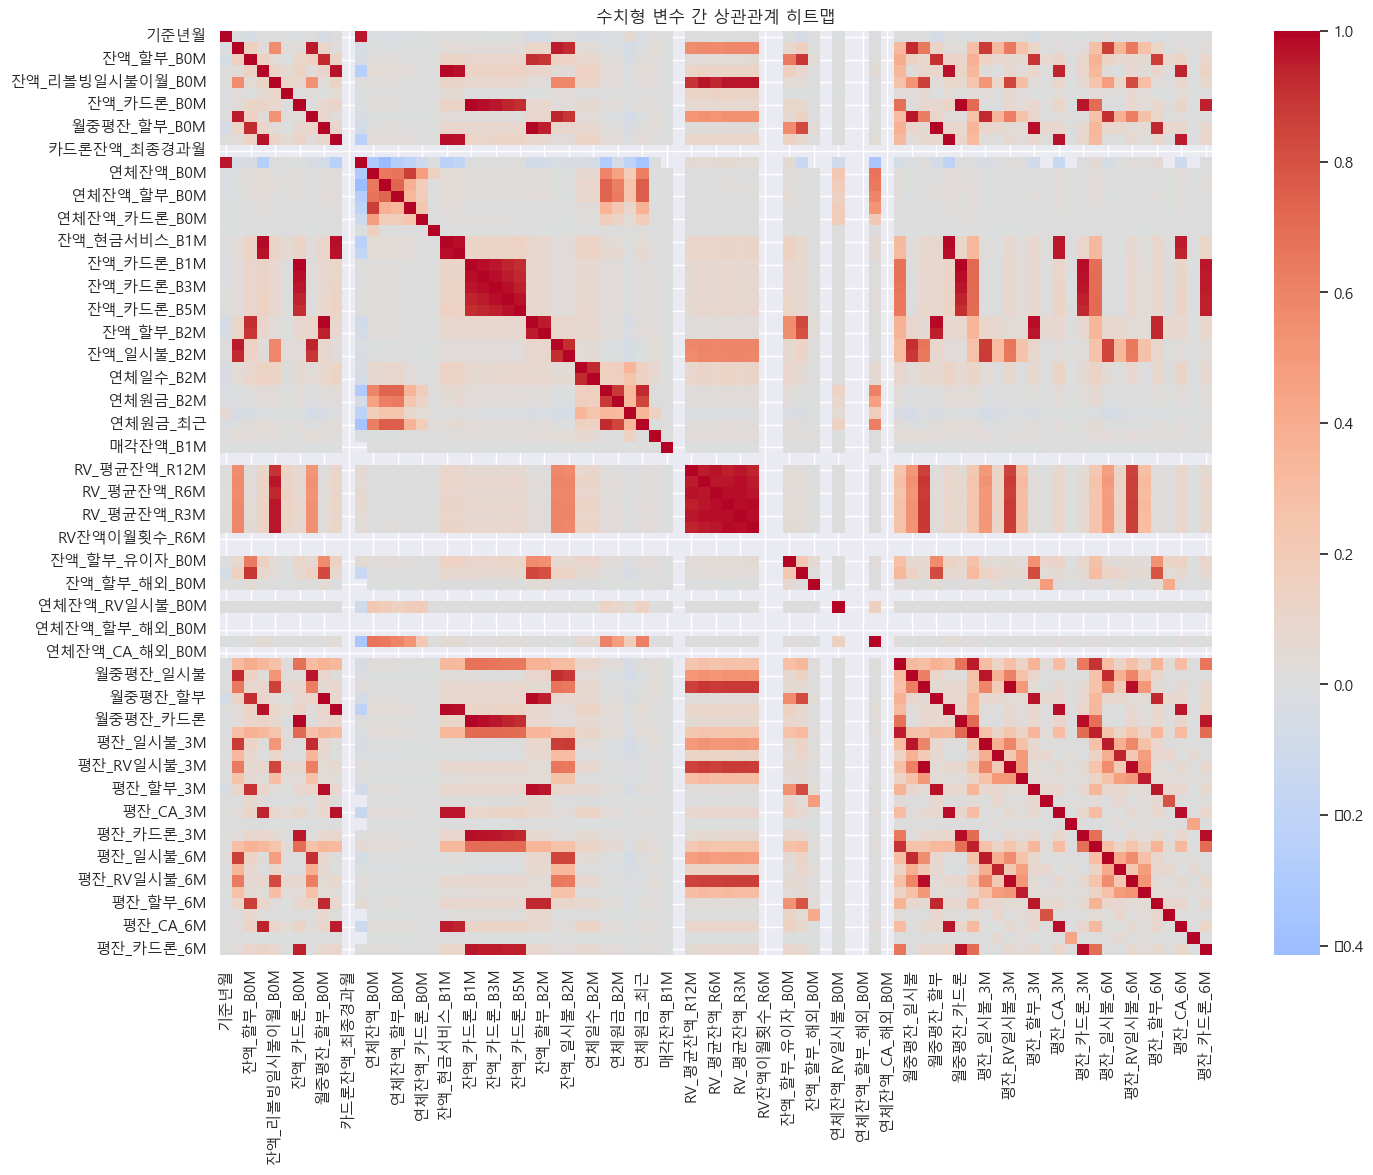

In [3]:
# 숫자형 컬럼만 추출
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns

# 상관계수 계산
corr_matrix = train_df[numeric_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", center=0)
plt.title('수치형 변수 간 상관관계 히트맵')
plt.show()

In [4]:
# 상관계수 절댓값 기준으로 높은 쌍 추리기
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

# 자기 자신 제외하고 상관관계 높은 상위 N쌍 출력
high_corr = corr_pairs[(corr_pairs < 1.0)].drop_duplicates()
print(high_corr[high_corr > 0.8].head(20))


잔액_카드론_B0M    잔액_카드론_B1M      0.994536
잔액_카드론_B1M    월중평잔_카드론        0.994479
월중평잔_할부_B0M   월중평잔_할부         0.993529
              잔액_할부_B1M       0.992217
월중평잔_카드론      잔액_카드론_B0M      0.991800
월중평잔_CA_B0M   월중평잔_CA         0.990595
월중평잔_RV일시불    평잔_RV일시불_3M     0.989991
월중평잔_할부       잔액_할부_B1M       0.988888
잔액_현금서비스_B1M  월중평잔_CA         0.984377
평잔_RV일시불_3M   평잔_RV일시불_6M     0.984271
RV_최대잔액_R3M   RV_최대잔액_R6M     0.983992
잔액_현금서비스_B0M  잔액_현금서비스_B1M    0.983802
RV_최대잔액_R3M   RV_평균잔액_R3M     0.982126
잔액_현금서비스_B1M  월중평잔_CA_B0M     0.980775
평잔_CA_3M      월중평잔_CA         0.980376
평잔_RV일시불_6M   월중평잔_RV일시불      0.980069
평잔_CA_6M      평잔_CA_3M        0.979813
RV_평균잔액_R3M   RV_최대잔액_R6M     0.979397
월중평잔_카드론      잔액_카드론_B2M      0.979232
잔액_카드론_B2M    잔액_카드론_B1M      0.978292
dtype: float64


In [5]:
# 각 컬럼별 유니크한 값 수 확인
for col in train_df.columns:
    print(f"{col}: {train_df[col].nunique()}")


기준년월: 6
ID: 400000
잔액_일시불_B0M: 46915
잔액_할부_B0M: 27079
잔액_현금서비스_B0M: 29834
잔액_리볼빙일시불이월_B0M: 16808
잔액_리볼빙CA이월_B0M: 799
잔액_카드론_B0M: 65512
월중평잔_일시불_B0M: 50150
월중평잔_할부_B0M: 40800
월중평잔_CA_B0M: 35383
카드론잔액_최종경과월: 1
연체일자_B0M: 201
연체잔액_B0M: 2178
연체잔액_일시불_B0M: 885
연체잔액_할부_B0M: 829
연체잔액_현금서비스_B0M: 251
연체잔액_카드론_B0M: 85
연체잔액_대환론_B0M: 7
잔액_현금서비스_B1M: 35119
잔액_현금서비스_B2M: 34837
잔액_카드론_B1M: 69829
잔액_카드론_B2M: 70506
잔액_카드론_B3M: 70916
잔액_카드론_B4M: 71113
잔액_카드론_B5M: 71894
잔액_할부_B1M: 42386
잔액_할부_B2M: 44400
잔액_일시불_B1M: 51622
잔액_일시불_B2M: 51500
연체일수_B1M: 3
연체일수_B2M: 3
연체원금_B1M: 6221
연체원금_B2M: 6652
연체일수_최근: 3
연체원금_최근: 4341
최종연체회차: 2
매각잔액_B1M: 2
최종연체개월수_R15M: 1
RV_평균잔액_R12M: 30785
RV_최대잔액_R12M: 35740
RV_평균잔액_R6M: 27326
RV_최대잔액_R6M: 29704
RV_평균잔액_R3M: 25309
RV_최대잔액_R3M: 26204
RV잔액이월횟수_R6M: 1
RV잔액이월횟수_R3M: 1
잔액_할부_유이자_B0M: 14101
잔액_할부_무이자_B0M: 24298
잔액_할부_해외_B0M: 349
연체잔액_일시불_해외_B0M: 1
연체잔액_RV일시불_B0M: 55
연체잔액_RV일시불_해외_B0M: 1
연체잔액_할부_해외_B0M: 1
연체잔액_CA_B0M: 788
연체잔액_CA_해외_B0M: 1
월중평잔: 112385
월중평잔_일시불: 49193
월중평잔_RV일시

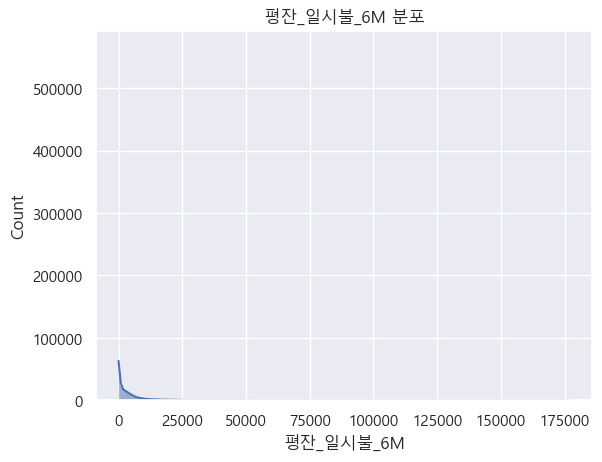

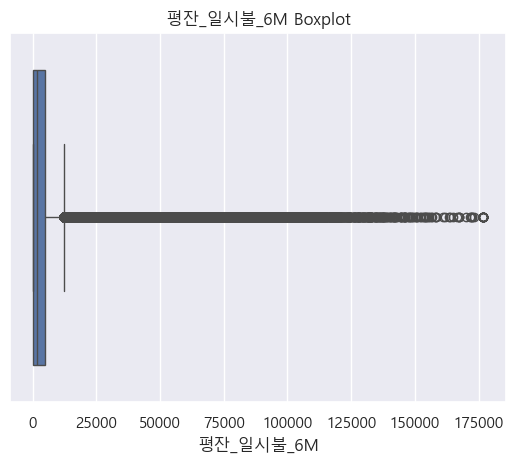

In [6]:
# 예: 평잔_일시불_6M의 분포
sns.histplot(train_df['평잔_일시불_6M'], kde=True)
plt.title('평잔_일시불_6M 분포')
plt.show()

# Boxplot: 이상치 포함 여부 확인
sns.boxplot(x=train_df['평잔_일시불_6M'])
plt.title('평잔_일시불_6M Boxplot')
plt.show()
